In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity

In [2]:
df = pd.read_csv("Healthcare_Imputation.csv")

df = df.interpolate(method='linear', limit_direction='forward', axis=0)

df_numeric = df.drop(columns=['Country', 'Year','Rank'])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

C:\Users\Admin\AppData\Local\Temp\ipykernel_17152\3373380982.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear', limit_direction='forward', axis=0)


In [3]:
kmo_all, kmo_model = calculate_kmo(df_scaled)
print("KMO Test:", kmo_model)  # Should be >0.6 ideally

chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)
print("Bartlett’s Test Chi-square:", chi_square_value, "p-value:", p_value)

KMO Test: 0.8567144561042855
Bartlett’s Test Chi-square: 824514.7266950854 p-value: 0.0


C:\Users\Admin\anaconda3\envs\Ease\Lib\site-packages\factor_analyzer\utils.py:249: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn('The inverse of the variance-covariance matrix '


Eigenvalues: [7.02850515e+00 4.00380729e+00 2.27740814e+00 8.63934143e-01
 7.72391192e-01 5.41594613e-01 7.07698568e-01 3.45164997e-01
 1.93924256e-01 1.04206806e-01 7.82162062e-02 3.27491807e-02
 3.02905378e-02 2.01050592e-02 6.18506210e-07 1.84884304e-06
 1.39084762e-06]


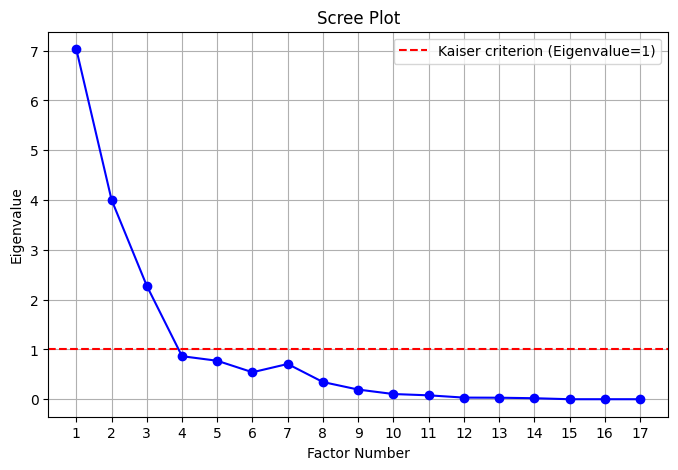

In [4]:
corr_matrix = np.corrcoef(df_scaled.T)
eigenvalues, _ = np.linalg.eig(corr_matrix)
print("Eigenvalues:", eigenvalues)

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='blue')
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser criterion (Eigenvalue=1)')
plt.title('Scree Plot')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, len(eigenvalues)+1))
plt.legend()
plt.grid(True)
plt.show()

In [5]:
n_factors = np.sum(eigenvalues > 1)  # Kaiser criterion

In [6]:
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(df_scaled)

C:\Users\Admin\anaconda3\envs\Ease\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,n_factors,3
,rotation,'varimax'
,method,'minres'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'median'
,svd_method,'randomized'
,rotation_kwargs,{}


In [7]:
loadings = pd.DataFrame(fa.loadings_, index=df_numeric.columns, columns=[f'Factor{i+1}' for i in range(n_factors)])
print("\nFactor Loadings:\n", loadings)

# Variance explained
variance = pd.DataFrame(fa.get_factor_variance(), 
                        index=['Variance', 'Proportional Variance', 'Cumulative Variance'], 
                        columns=[f'Factor{i+1}' for i in range(n_factors)])
print("\nVariance Explained:\n", variance)


Factor Loadings:
                                                      Factor1   Factor2  \
LE_at_birth                                         0.882206 -0.015640   
Doctors_Per_10000                                   0.843461 -0.044282   
Access_to_Electricity                               0.887393 -0.017007   
Unnamed_03                                         -0.005569  0.999354   
Unnamed_02                                         -0.005596  0.999354   
Unnamed_01                                         -0.005631  0.999354   
Unnamed_0                                          -0.005701  0.999354   
Carbon_dioxide_emissions_per_capita_production_...  0.569821  0.044869   
Gender_Development_Index                            0.675167  0.004983   
Gender_Inequality_Index                            -0.915602  0.002443   
Human_Development_Index                             0.992031 -0.017496   
Inequalityadjusted_Human_Development_Index          0.988058 -0.014530   
Planetary_pressures